# Brain Tumor MRI Classification
## Dataset Exploration

This notebook performs exploratory data analysis on the Brain MRI dataset.

Objectives:

- Understand dataset structure
- Verify labels
- Analyze class distribution
- Inspect image properties
- Detect corrupted files
- Understand image statistics
- Prepare data for model development

No model training is performed in this notebook.

## IMPORTS

In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from torchvision.datasets import ImageFolder

from configs.paths import TRAIN_DIR, TEST_DIR

## REPRODUCIBILITY

In [17]:
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

## DATASET PATHS

In [18]:
print("Training directory:")
print(TRAIN_DIR)

print("\nTesting directory:")
print(TEST_DIR)

assert TRAIN_DIR.exists()
assert TEST_DIR.exists()

print("Paths verified ✓")

Training directory:
/Users/nafisebahoosh/Developer/DataScience/brain-tumor-classification/data/raw/brain_mri/train

Testing directory:
/Users/nafisebahoosh/Developer/DataScience/brain-tumor-classification/data/raw/brain_mri/test
Paths verified ✓


## LOAD DATASET

In [19]:
train_dataset = ImageFolder(
    root=TRAIN_DIR
)

test_dataset = ImageFolder(
    root=TEST_DIR
)

## DATASET OVERVIEW

In [5]:
print(
    f"""
Dataset Overview
----------------
Training samples : {len(train_dataset)}
Testing samples  : {len(test_dataset)}

Classes:
{train_dataset.classes}

Class mapping:
{train_dataset.class_to_idx}
"""
)


Dataset Overview
----------------
Training samples : 11752
Testing samples  : 1308

Classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

Class mapping:
{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}



## CREATE DATASET METADATA TABLE

In [6]:
def create_metadata(dataset):
    records = []

    for filepath, label in dataset.samples:

        path = Path(filepath)

        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode

        records.append(
            {
                "filepath": str(path),
                "filename": path.name,
                "label": label,
                "class_name": dataset.classes[label],
                "width": width,
                "height": height,
                "mode": mode,
                "extension": path.suffix.lower(),
            }
        )

    return pd.DataFrame(records)


train_df = create_metadata(train_dataset)

test_df = create_metadata(test_dataset)
train_df.head()


,filepath,filename,label,class_name,width,height,mode,extension
0,/Users/nafisebahoosh/Developer/DataScience/bra...,bright_img_100_1307.png,0,glioma_tumor,256,256,RGB,.png
1,/Users/nafisebahoosh/Developer/DataScience/bra...,bright_img_102_1309.png,0,glioma_tumor,256,256,RGB,.png
2,/Users/nafisebahoosh/Developer/DataScience/bra...,bright_img_103_1310.png,0,glioma_tumor,256,256,RGB,.png
3,/Users/nafisebahoosh/Developer/DataScience/bra...,bright_img_105_1312.png,0,glioma_tumor,256,256,RGB,.png
4,/Users/nafisebahoosh/Developer/DataScience/bra...,bright_img_106_1313.png,0,glioma_tumor,256,256,RGB,.png


## DATASET STATISTICS

In [7]:
train_df.info()
train_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11752 entries, 0 to 11751
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filepath    11752 non-null  object
 1   filename    11752 non-null  object
 2   label       11752 non-null  int64 
 3   class_name  11752 non-null  object
 4   width       11752 non-null  int64 
 5   height      11752 non-null  int64 
 6   mode        11752 non-null  object
 7   extension   11752 non-null  object
dtypes: int64(3), object(5)
memory usage: 734.6+ KB


,label,width,height
count,11752.000000,11752.0,11752.0
mean,1.421715,256.0,256.0
std,1.167526,0.0,0.0
min,0.000000,256.0,256.0
25%,0.000000,256.0,256.0
50%,1.000000,256.0,256.0
75%,3.000000,256.0,256.0
max,3.000000,256.0,256.0


## CLASS DISTRIBUTION

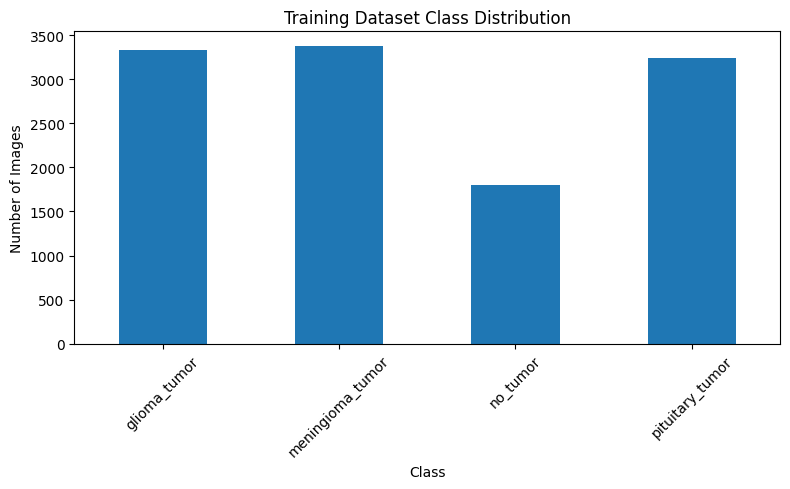

In [8]:
class_distribution = (
    train_df["class_name"]
    .value_counts()
    .sort_index()
)

class_distribution
plt.figure(figsize=(8,5))

class_distribution.plot(
    kind="bar"
)

plt.title(
    "Training Dataset Class Distribution"
)

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## CHECK CLASS BALANCE

In [9]:
imbalance_ratio = (
    class_distribution.max()
    /
    class_distribution.min()
)

print(
    f"Imbalance ratio: {imbalance_ratio:.2f}"
)

Imbalance ratio: 1.87


## IMAGE DIMENTION ANALYSIS

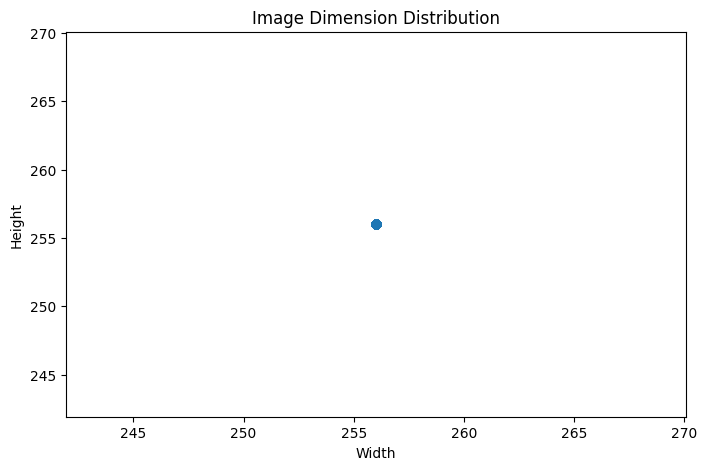

In [10]:
train_df[
    [
        "width",
        "height"
    ]
].describe()

# most common size
(
train_df
[
["width","height"]
]
.value_counts()
.head(10)
)


#visualization
plt.figure(figsize=(8,5))

plt.scatter(
    train_df["width"],
    train_df["height"],
    alpha=0.5
)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title(
    "Image Dimension Distribution"
)

plt.show()

## IMAGE MODE ANALYSIS

In [11]:
train_df["mode"].value_counts()

mode
RGB    11752
Name: count, dtype: int64

## FILE EXTENSION ANALYSIS

In [12]:
train_df["extension"].value_counts()

extension
.png    11752
Name: count, dtype: int64

## CORRUPTED IMAGE DETECTION

In [13]:
def find_corrupted_images(df):

    corrupted=[]

    for filepath in df["filepath"]:

        try:
            with Image.open(filepath) as img:
                img.verify()

        except Exception:
            corrupted.append(filepath)

    return corrupted

corrupted_images = find_corrupted_images(train_df)

print(
    f"Corrupted images: {len(corrupted_images)}"
)

Corrupted images: 0


## VISUALIZE RANDOM SAMPLES

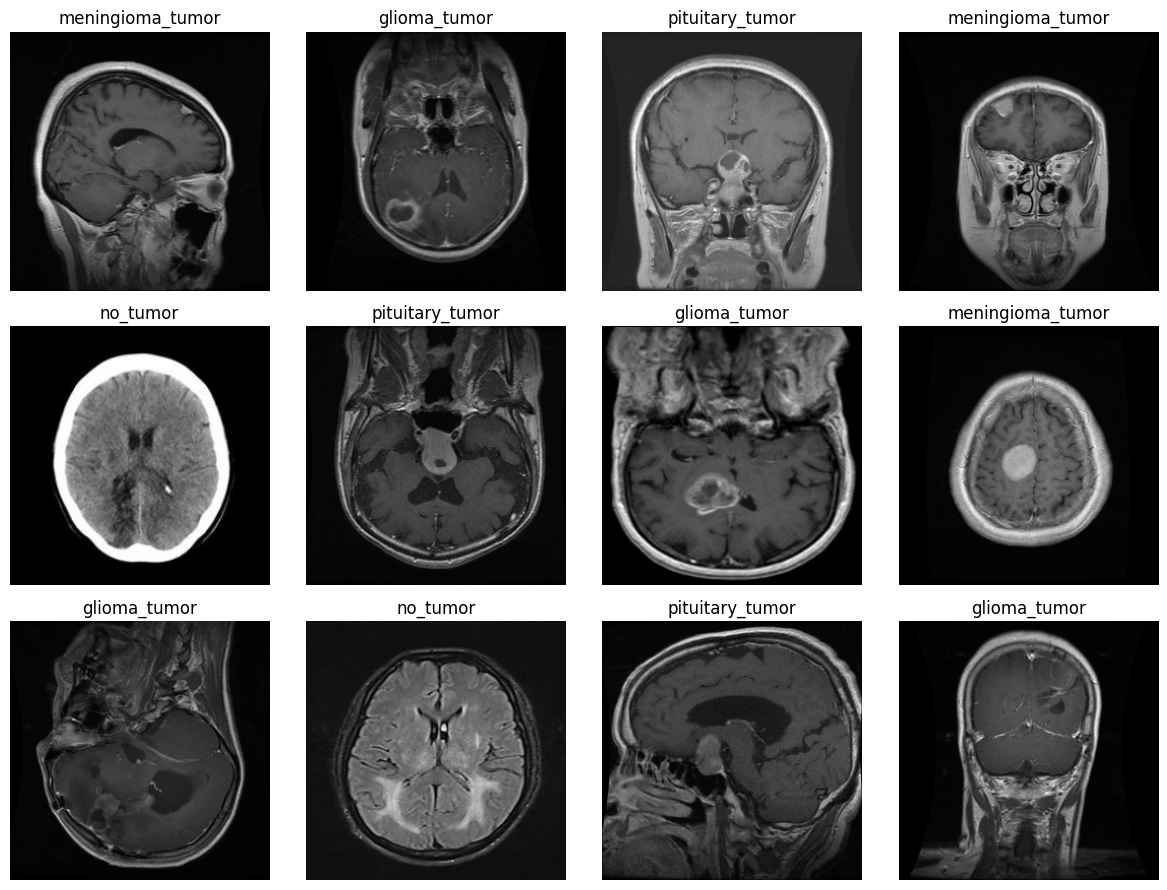

In [14]:
def show_random_images(
    dataset,
    n_images=12,
    seed=42
):

    rng = np.random.default_rng(seed)

    indices = rng.choice(
        len(dataset),
        size=n_images,
        replace=False
    )


    rows = 3
    cols = 4


    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12,9)
    )

    axes = axes.flatten()


    for ax, idx in zip(axes, indices):

        image, label = dataset[idx]

        ax.imshow(image)

        ax.set_title(
            dataset.classes[label]
        )

        ax.axis("off")


    plt.tight_layout()

    plt.show()

show_random_images(train_dataset)

## PIXEL STATISTICS

In [15]:
def calculate_pixel_statistics(dataset):
    """
    Calculate channel-wise mean and standard deviation.

    Returns:
        mean: RGB channel means
        std: RGB channel standard deviations
    """

    channel_sum = np.zeros(3)
    channel_sum_squared = np.zeros(3)

    total_pixels = 0

    for image, _ in dataset:

        image_array = np.array(image) / 255.0

        pixels = image_array.reshape(-1, 3)

        channel_sum += pixels.sum(axis=0)

        channel_sum_squared += (
            pixels ** 2
        ).sum(axis=0)

        total_pixels += pixels.shape[0]


    mean = channel_sum / total_pixels

    std = np.sqrt(
        (
            channel_sum_squared / total_pixels
        )
        -
        (mean ** 2)
    )

    return mean, std

mean, std = calculate_pixel_statistics(train_dataset)

print("Mean:", mean)
print("Std:", std)

Mean: [0.21759173 0.21759173 0.21759173]
Std: [0.20262772 0.20262772 0.20262772]


# Conclusion

The Brain Tumor MRI dataset was successfully explored and validated.

Key findings:

- The dataset contains 11,752 training images and 1,308 testing images.
- The task is a four-class classification problem:
    - glioma_tumor
    - meningioma_tumor
    - no_tumor
    - pituitary_tumor

- The dataset structure is compatible with PyTorch ImageFolder.
- No corrupted images were detected.
- All images are RGB PNG files.
- The dataset has a moderate class imbalance with an imbalance ratio of 1.87, which is acceptable for initial model training.
- Images require resizing before training because CNN architectures require fixed spatial dimensions.
- Pixel statistics were calculated for understanding the dataset distribution and future preprocessing decisions.

The dataset is ready for building the PyTorch training pipeline.